<a href="https://colab.research.google.com/github/lawilbee/mte544/blob/main/Lab1/Part2/MTE544_A1_P2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install matplotlib numpy

In [ ]:
%%writefile driveSim.py
import numpy as np
import matplotlib.pyplot as plt
import os

# Simulate robot motion over 30s with 0.1s time stamps and
# initial position at the origin
def simulate(v_func, w_func, t_total=30.0, dt=0.1, pos_init=(0.0, 0.0, 0.0)):
    # determine # of steps and set time array
    n_steps = int(round(t_total / dt)) + 1
    t = np.linspace(0.0, t_total, n_steps)

    # initialize data arrays
    x = np.zeros(n_steps)
    y = np.zeros(n_steps)
    theta = np.zeros(n_steps)
    v_hist = np.zeros(n_steps)
    w_hist = np.zeros(n_steps)

    # Initialize the robot position
    x[0], y[0], theta[0] = pos_init
    # Iterate functions over the range at given timestamps
    for k in range(n_steps - 1):
        v_k = v_func(t[k])
        w_k = w_func(t[k])
        # store linear and angular velos
        v_hist[k] = v_k
        w_hist[k] = w_k
        # store position
        x[k + 1] = x[k] + v_k * np.cos(theta[k]) * dt
        y[k + 1] = y[k] + v_k * np.sin(theta[k]) * dt
        theta[k + 1] = theta[k] + w_k * dt
    # record final-step velocities to fix plot suddenly falling to 0
    v_hist[-1] = v_func(t[-1])
    w_hist[-1] = w_func(t[-1])

    return t, x, y, theta, v_hist, w_hist

# Plot the 2D trajectory and each variable against time
# for a given test case
def plot_case(t, x, y, theta, v_hist, w_hist, title, fname_prefix, out_dir='.'):

    # 2D trajectory plot (x vs y)
    fig1, ax1 = plt.subplots(figsize=(6, 6))
    ax1.plot(x, y, linewidth=2)
    ax1.plot(x[0], y[0], 'go', label='Start')
    ax1.plot(x[-1], y[-1], 'ro', label='End')
    ax1.set_xlabel('x [m]')
    ax1.set_ylabel('y [m]')
    ax1.set_title(f'2D Trajectory: {title}')
    ax1.axis('equal')
    ax1.grid(True)
    ax1.legend()
    fig1.tight_layout()
    fig1.savefig(os.path.join(out_dir, f'{fname_prefix}_trajectory.png'), dpi=150)
    # plt.close(fig1)
    plt.show(fig1)

    # Time-series plots: x(t), y(t), theta(t)
    fig2, axs = plt.subplots(3, 1, figsize=(8, 9), sharex=True)

    axs[0].plot(t, x, linewidth=2)
    axs[0].set_ylabel('x [m]')
    axs[0].set_title(f'Pos vs time: {title}')
    axs[0].grid(True)

    axs[1].plot(t, y, linewidth=2, color='tab:orange')
    axs[1].set_ylabel('y [m]')
    axs[1].grid(True)

    axs[2].plot(t, theta, linewidth=2, color='tab:green')
    axs[2].set_ylabel(r'$\theta$ [rad]')
    axs[2].set_xlabel('time [s]')
    axs[2].grid(True)

    fig2.tight_layout()
    fig2.savefig(os.path.join(out_dir, f'{fname_prefix}_pos_vs_time.png'), dpi=150)
    # plt.close(fig2)
    plt.show(fig2)

    # Time-series plots: v(t), w(t)
    fig3, axs2 = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
    axs2[0].plot(t, v_hist, linewidth=2)
    axs2[0].set_ylabel('v [m/s]')
    axs2[0].set_title(f'Inputs vs time: {title}')
    axs2[0].grid(True)

    axs2[1].plot(t, w_hist, linewidth=2, color='tab:red')
    axs2[1].set_ylabel(r'$\omega$ [rad/s]')
    axs2[1].set_xlabel('time [s]')
    axs2[1].grid(True)

    fig3.tight_layout()
    fig3.savefig(os.path.join(out_dir, f'{fname_prefix}_inputs_vs_time.png'), dpi=150)
    # plt.close(fig3)
    plt.show(fig3)

# Calculate wheel speeds for constat velo profiles in (a).i
def wheelSpeed(v_func, w_func):
    T = 0.3 # Track length (m)
    r = 0.15 # Wheel radius (m)
    v = v_func(0) # get v at t=0
    w = w_func(0) # get w at t=0
    v_l = v - T*w/2 # left speed
    v_r = v + T*w/2 # right speed
    u_l = v_l/r # Left wheel speed
    u_r = v_r/r # Right wheel speed
    return u_l, u_r

# Run the simulation for Part 2
def runSim():
    T_TOTAL = 30.0 # total time (s)
    DT = 0.1 # time step (s)
    # Save plots to path
    # SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__))
    # PLOTS_DIR = os.path.join(SCRIPT_DIR, 'plots')
    PLOTS_DIR = './plots'
    # os.makedirs(PLOTS_DIR, exist_ok=True)
    os.makedirs(PLOTS_DIR, exist_ok=True)


    # Define the 4 test cases required
    cases = [
        {
            'name': 'i.1: v=1, w=0',
            'prefix': 'i_1',
            'v_func': lambda t: 1.0,
            'w_func': lambda t: 0.0,
        },
        {
            'name': 'i.2: v=0, w=0.5',
            'prefix': 'i_2',
            'v_func': lambda t: 0.0,
            'w_func': lambda t: 0.5,
        },
        {
            'name': 'i.3: v=1, w=0.5',
            'prefix': 'i_3',
            'v_func': lambda t: 1.0,
            'w_func': lambda t: 0.5,
        },
        {
            'name': 'ii: v(t)=1+0.2sin(t), w(t)=0.2+0.6cos(t)',
            'prefix': 'ii',
            'v_func': lambda t: 1.0 + 0.2 * np.sin(t),
            'w_func': lambda t: 0.2 + 0.6 * np.cos(t),
        },
    ]
    # Run the 4 test cases
    for case in cases:
        # Run model simulation
        t, x, y, theta, v_hist, w_hist = simulate(
            case['v_func'], case['w_func'], t_total=T_TOTAL, dt=DT
        )
        # Plot sim results
        plot_case(t, x, y, theta, v_hist, w_hist, case['name'], case['prefix'],PLOTS_DIR)
        # Solve and display wheel speeds
        if(case['prefix'] != 'ii'):
            u_l, u_r = wheelSpeed(case['v_func'], case['w_func'])
            print(f"\n {case['name']}: u_l={u_l:.3f}, u_r={u_r:.3f} (rad/s)")


Writing driveSim.py


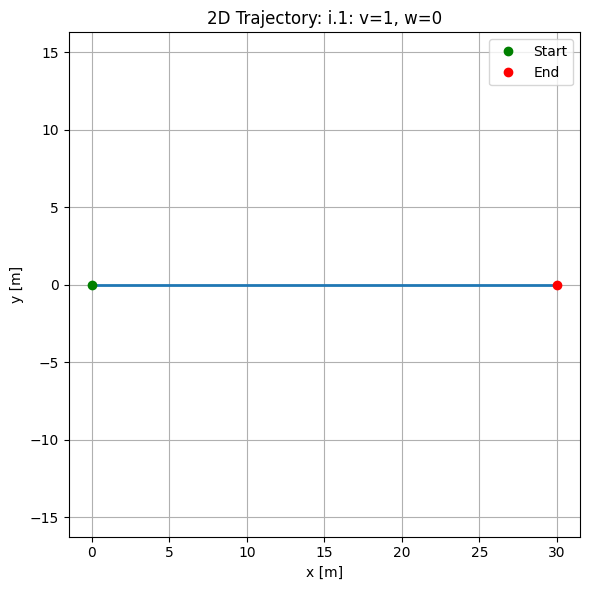

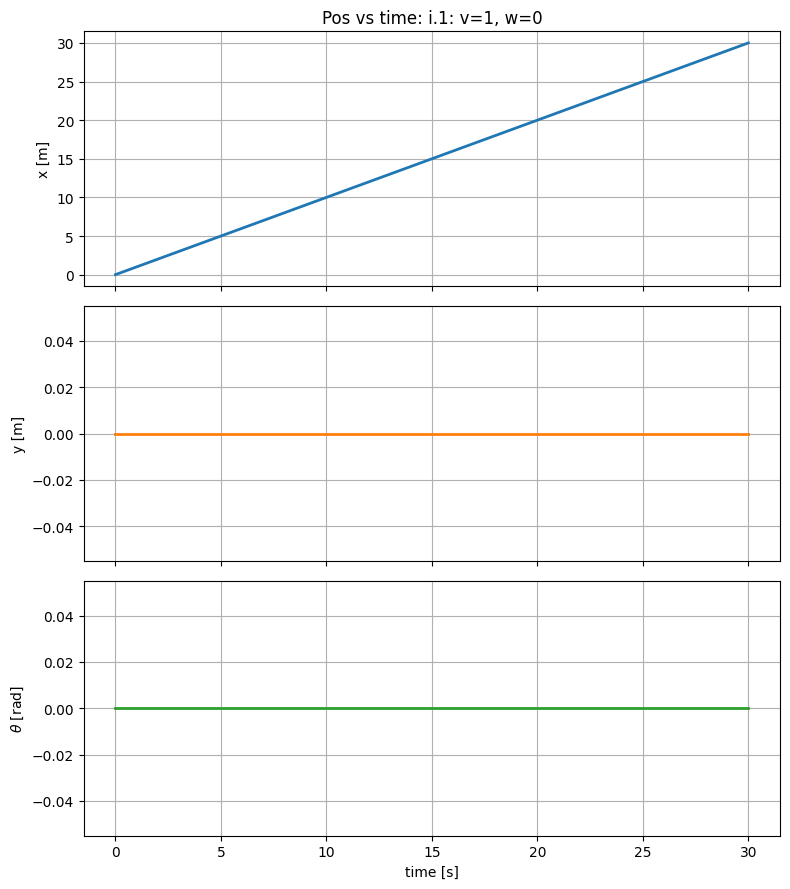

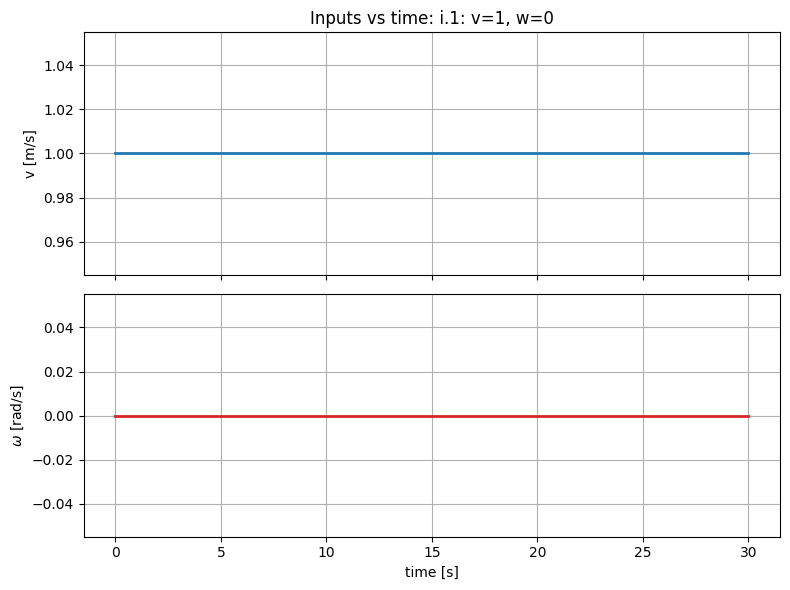


 i.1: v=1, w=0: u_l=6.667, u_r=6.667 (rad/s)


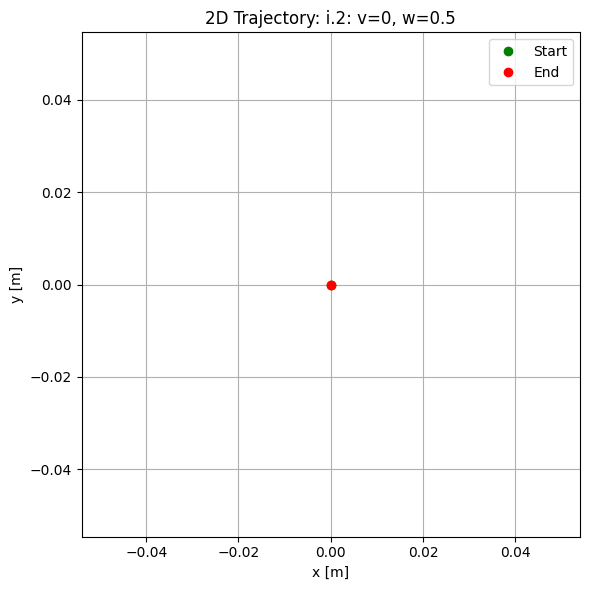

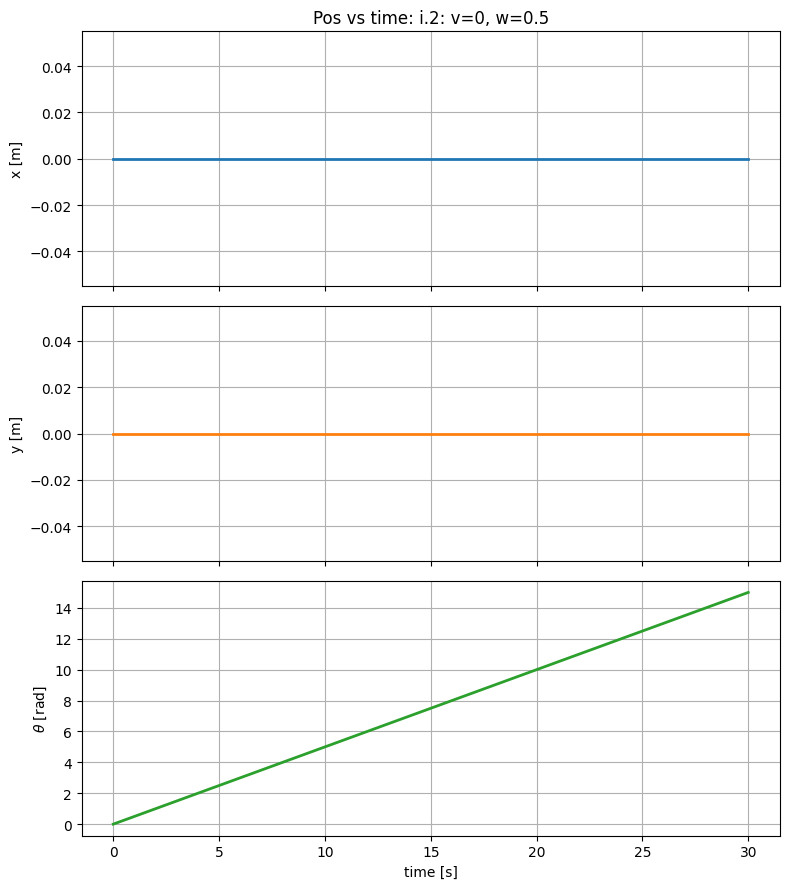

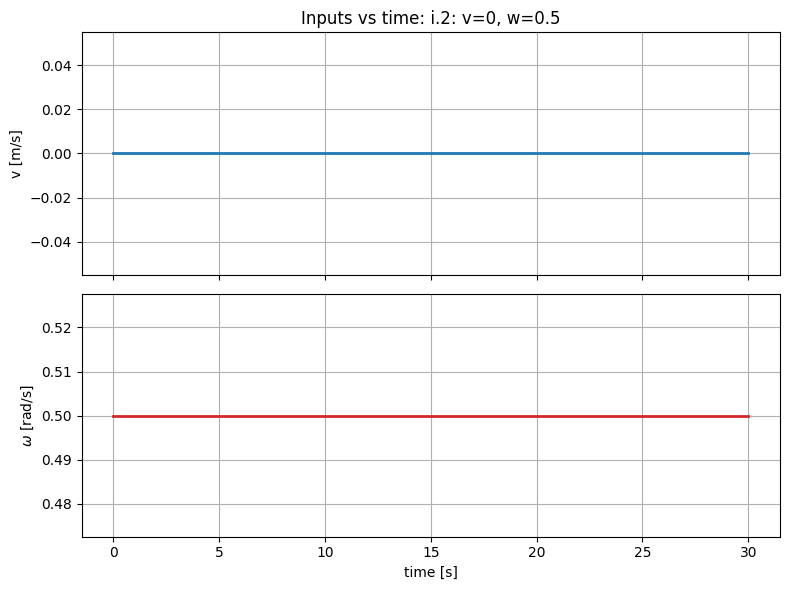


 i.2: v=0, w=0.5: u_l=-0.500, u_r=0.500 (rad/s)


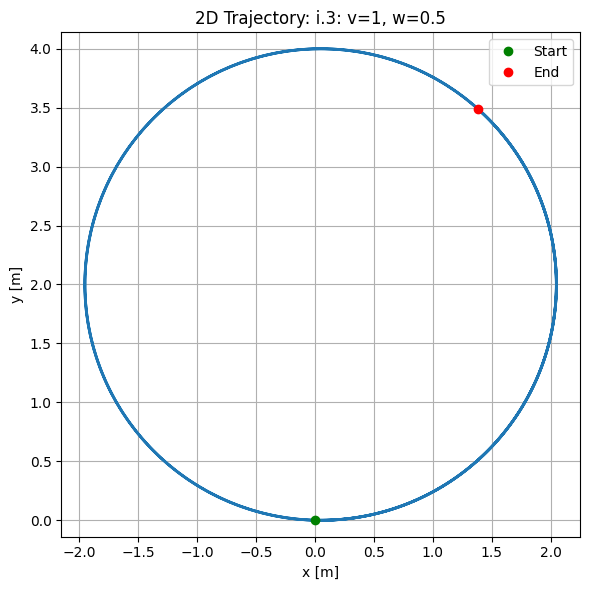

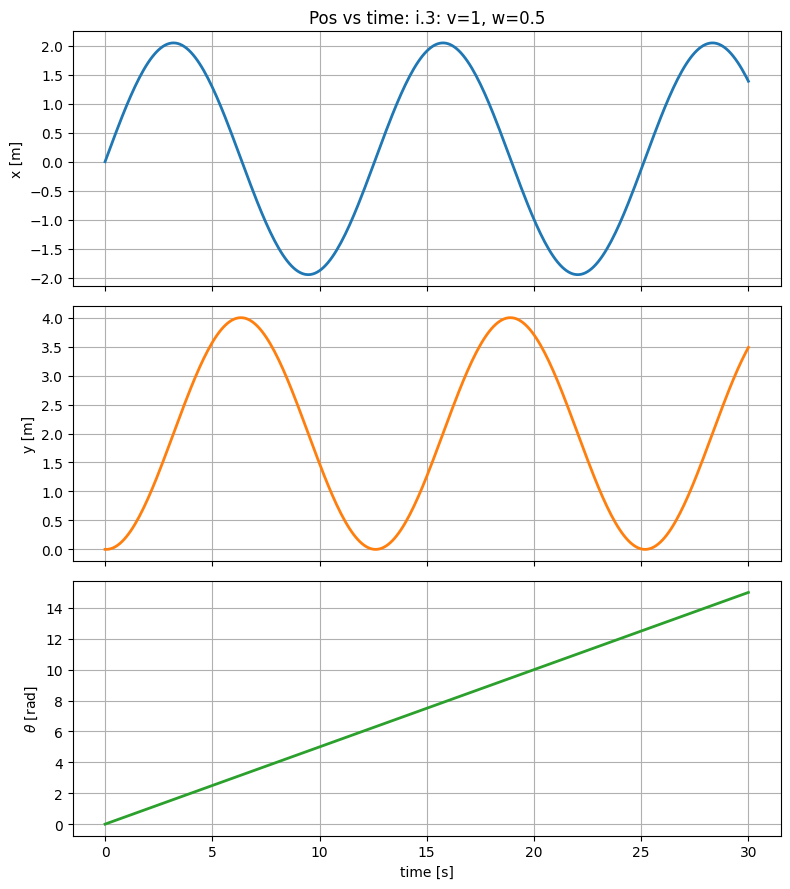

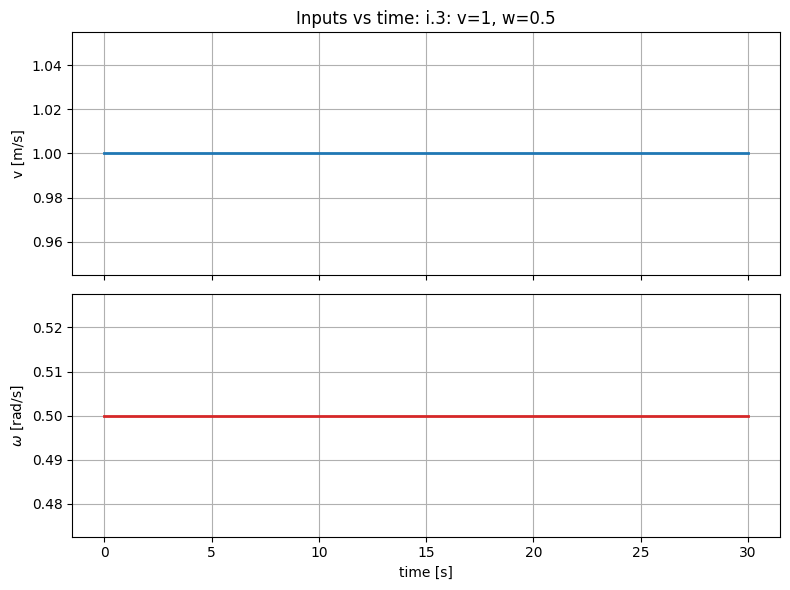


 i.3: v=1, w=0.5: u_l=6.167, u_r=7.167 (rad/s)


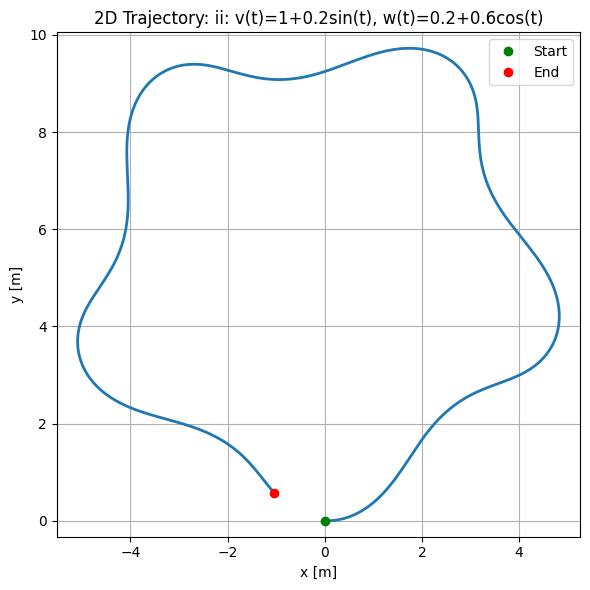

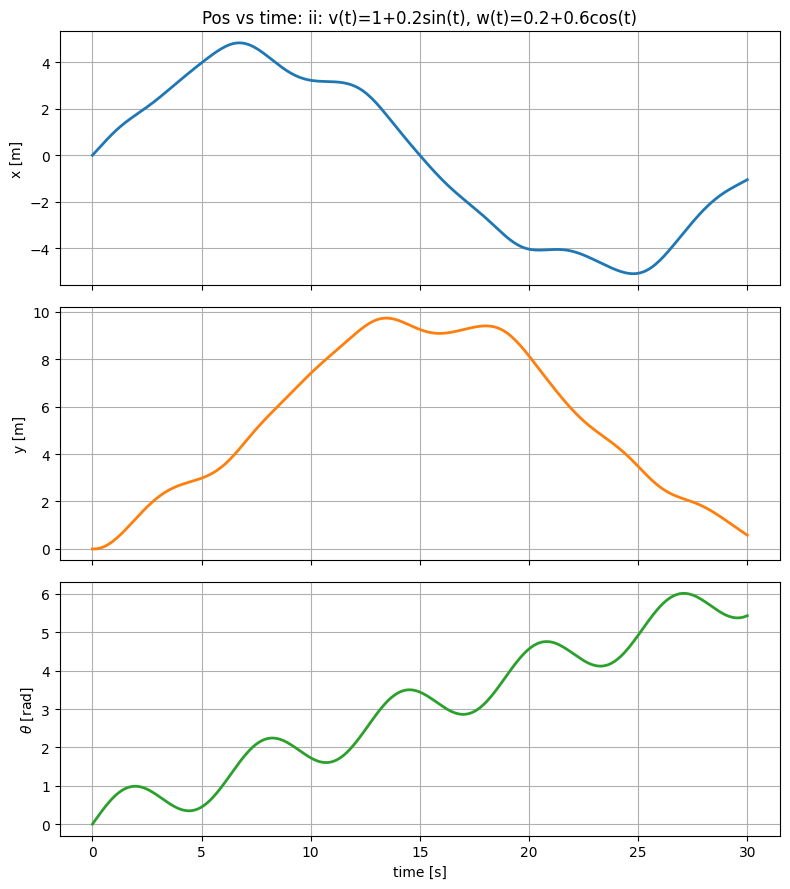

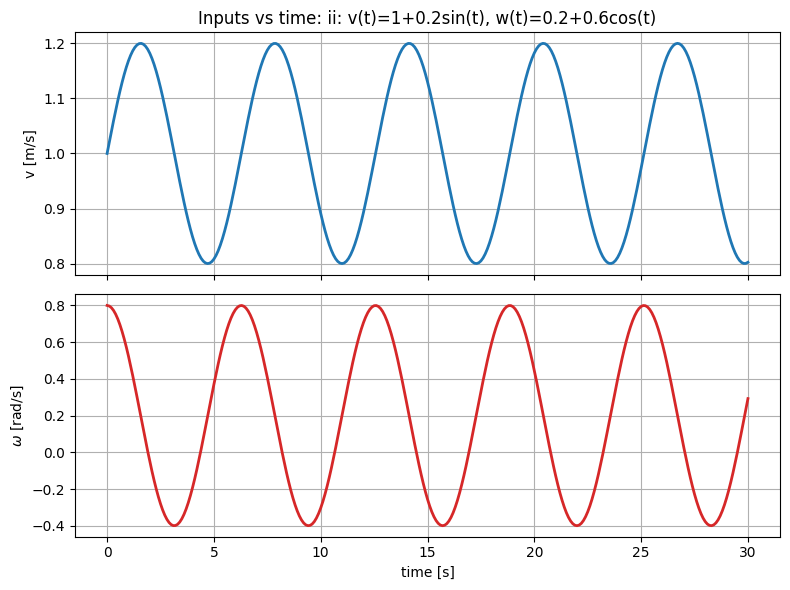

In [ ]:
import importlib
import driveSim
importlib.reload(driveSim)
from driveSim import runSim

def main():
    runSim()

if __name__ == "__main__":
    main()
